<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #16a34a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Criterios de División: Índice Gini, Entropía y MSE 📐🔬
      </h1>
      <p style="margin: 6px 0 0 0; color: #16a34a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Splitting Criteria
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #15803d; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #16a34a; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/01_Criterios_de_Division_Gini_Entropia_y_MSE.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. ¿Por qué se necesita un criterio matemático de pureza? 🧭

El **Cuaderno 00** de este módulo describió el algoritmo CART como una búsqueda voraz que, en cada nodo, prueba todas las variables y todos los umbrales candidatos y se queda con la división que "más mejora la pureza" — pero nunca formalizó qué significa exactamente "pureza". Esa es la tarea de este cuaderno.

Intuitivamente, un nodo es **puro** si casi todas sus observaciones pertenecen a una misma clase (clasificación) o tienen valores de $y$ muy similares entre sí (regresión), e **impuro** si está mezclado. Pero "casi todas" y "muy similares" no son medidas numéricas — se necesita una función matemática $I(t)$ que tome la distribución de clases (o de valores) en un nodo $t$ y devuelva un número: bajo cuando el nodo es puro, alto cuando está mezclado. Ese número es lo que CART compara antes y después de cada división candidata para decidir cuál es "mejor". Este cuaderno formaliza las tres funciones de impureza más usadas: **Gini** y **Entropía** (clasificación) y **MSE** (regresión), y las aplica sobre el mismo dataset `abandono_clientes_telecom.csv` del Cuaderno 00 para que cada fórmula tenga un número real, verificable, detrás.

### 1.1 Preparación: reconstruyendo los datos del Cuaderno 00

Se repite exactamente la misma codificación de variables usada en el Cuaderno 00 (mapeo binario para `factura_electronica`, `OrdinalEncoder` para `tipo_contrato`, One-Hot para `soporte_tecnico`) para mantener resultados comparables entre ambos cuadernos.

In [1]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "abandono_clientes_telecom.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df_telecom = pd.read_csv(load_dataset("abandono_clientes_telecom.csv"))

df_prep = df_telecom.copy()
df_prep["factura_electronica"] = df_prep["factura_electronica"].map({"No": 0, "Si": 1})

orden_contrato = [["Mes_a_Mes", "Un_Ano", "Dos_Anos"]]
encoder_contrato = OrdinalEncoder(categories=orden_contrato)
df_prep["tipo_contrato_ord"] = encoder_contrato.fit_transform(df_prep[["tipo_contrato"]]).astype(int)

soporte_dummies = pd.get_dummies(df_prep["soporte_tecnico"], prefix="soporte").astype(int)
df_prep = pd.concat([df_prep, soporte_dummies], axis=1)

feature_cols = ["antiguedad_meses", "cargo_mensual", "cargos_totales",
                 "tipo_contrato_ord", "factura_electronica",
                 "soporte_No", "soporte_Si", "soporte_Sin_Internet"]

X = df_prep[feature_cols]
y = df_prep["churn"]

p0_raiz = (y == 0).mean()
p1_raiz = (y == 1).mean()
print(f"Nodo raiz: n={len(y)}  p(No_Churn)={p0_raiz:.4f}  p(Churn)={p1_raiz:.4f}")

Nodo raiz: n=2500  p(No_Churn)=0.7112  p(Churn)=0.2888


---
## 2. Impureza de Gini 📊

El **índice de Gini** mide la impureza de un nodo $t$ con $K$ clases como:

$$I_G(t) = 1 - \sum_{k=1}^{K} p(k \mid t)^2$$

donde $p(k \mid t)$ es la proporción de observaciones de la clase $k$ en el nodo $t$. Intuición: si el nodo es puro (todas las observaciones de una sola clase, $p=1$ para esa clase), $I_G = 1 - 1^2 = 0$ — impureza mínima. Si las clases están perfectamente balanceadas en un problema binario ($p_0 = p_1 = 0.5$), $I_G = 1 - (0.5^2 + 0.5^2) = 0.5$ — el **máximo** posible en el caso binario.

Aplicado al nodo raíz del dataset completo (2500 clientes, $p(\text{No\_Churn}) = 0.7112$, $p(\text{Churn}) = 0.2888$, del Cuaderno 00):

In [2]:
gini_raiz = 1 - (p0_raiz**2 + p1_raiz**2)
print(f"Gini(raiz) = 1 - ({p0_raiz:.4f}^2 + {p1_raiz:.4f}^2) = {gini_raiz:.4f}")

Gini(raiz) = 1 - (0.7112^2 + 0.2888^2) = 0.4108


**Resultado:** $I_G(\text{raíz}) = 0.4108$ — bastante cercano al máximo teórico de 0.5 (esperable, dado que 71%/29% no está lejos de un balance perfecto), lo que confirma numéricamente que el nodo raíz es efectivamente impuro. Cualquier división que CART evalúe se comparará contra este valor: si logra reducirlo, es una división útil.

---
## 3. Entropía de Shannon y Ganancia de Información 🔬

La **entropía de Shannon**, tomada de la teoría de la información, es la otra función de impureza estándar para clasificación:

$$H(t) = -\sum_{k=1}^{K} p(k \mid t) \log_2 p(k \mid t)$$

Su interpretación es distinta a la de Gini pero apunta en la misma dirección: mide la cantidad de "incertidumbre" o "sorpresa promedio" al observar la clase de una observación tomada al azar del nodo $t$. Un nodo puro tiene $H = 0$ (no hay incertidumbre: se sabe con certeza la clase). Un nodo binario perfectamente balanceado tiene $H = -(0.5 \log_2 0.5 + 0.5 \log_2 0.5) = 1$ — el máximo posible en el caso binario (nótese que el máximo de entropía es **1**, el doble que el máximo de Gini, que es 0.5 — las dos escalas no son directamente comparables en magnitud, solo en la dirección del ordenamiento que producen).

In [3]:
entropia_raiz = -(p0_raiz * np.log2(p0_raiz) + p1_raiz * np.log2(p1_raiz))
print(f"H(raiz) = -({p0_raiz:.4f}*log2({p0_raiz:.4f}) + {p1_raiz:.4f}*log2({p1_raiz:.4f})) = {entropia_raiz:.4f}")

H(raiz) = -(0.7112*log2(0.7112) + 0.2888*log2(0.2888)) = 0.8672


**Resultado:** $H(\text{raíz}) = 0.8672$, también cerca de su máximo teórico (1.0). La **Ganancia de Información** (*Information Gain*, IG) es a la entropía lo que la "reducción de Gini" es al índice de Gini: la reducción de impureza que produce una división específica, calculada como la entropía del nodo padre menos el promedio ponderado (por tamaño) de las entropías de los nodos hijos:

$$\text{IG} = H(\text{padre}) - \sum_{c \in \{\text{izq, der}\}} \frac{n_c}{n_{\text{padre}}} H(c)$$

Se aplica esta fórmula —y su análoga con Gini— a la división real que CART eligió como raíz del árbol en el Cuaderno 00: **`tipo_contrato_ord <= 0.5`**, es decir, separar a los clientes con contrato `Mes_a_Mes` (izquierda) del resto (derecha).

In [4]:
mask_mes_a_mes = X["tipo_contrato_ord"] <= 0.5
y_izq, y_der = y[mask_mes_a_mes], y[~mask_mes_a_mes]
n = len(y)
n_izq, n_der = len(y_izq), len(y_der)

p1_izq = (y_izq == 1).mean(); p0_izq = 1 - p1_izq
p1_der = (y_der == 1).mean(); p0_der = 1 - p1_der

gini_izq = 1 - (p0_izq**2 + p1_izq**2)
gini_der = 1 - (p0_der**2 + p1_der**2)
ent_izq = -(p0_izq * np.log2(p0_izq) + p1_izq * np.log2(p1_izq))
ent_der = -(p0_der * np.log2(p0_der) + p1_der * np.log2(p1_der))

gini_hijos = (n_izq / n) * gini_izq + (n_der / n) * gini_der
ent_hijos = (n_izq / n) * ent_izq + (n_der / n) * ent_der
ganancia_gini = gini_raiz - gini_hijos
ganancia_info = entropia_raiz - ent_hijos

print(f"Rama Mes_a_Mes:       n={n_izq}  p(Churn)={p1_izq:.4f}  Gini={gini_izq:.4f}  Entropia={ent_izq:.4f}")
print(f"Rama Un_Ano/Dos_Anos: n={n_der}  p(Churn)={p1_der:.4f}  Gini={gini_der:.4f}  Entropia={ent_der:.4f}")
print(f"\nGini ponderado hijos     = {gini_hijos:.4f}  ->  Ganancia Gini        = {ganancia_gini:.4f}")
print(f"Entropia ponderada hijos = {ent_hijos:.4f}  ->  Ganancia de Informacion = {ganancia_info:.4f}")

arbol_verif = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X, y)
print(f"\nVerificacion sklearn (max_depth=1): impureza raiz={arbol_verif.tree_.impurity[0]:.4f}, n_izq={arbol_verif.tree_.n_node_samples[1]}, n_der={arbol_verif.tree_.n_node_samples[2]}")

Rama Mes_a_Mes:       n=1379  p(Churn)=0.4206  Gini=0.4874  Entropia=0.9817
Rama Un_Ano/Dos_Anos: n=1121  p(Churn)=0.1267  Gini=0.2213  Entropia=0.5482

Gini ponderado hijos     = 0.3681  ->  Ganancia Gini        = 0.0427
Entropia ponderada hijos = 0.7874  ->  Ganancia de Informacion = 0.0798

Verificacion sklearn (max_depth=1): impureza raiz=0.4108, n_izq=1379, n_der=1121


**Lectura:** dividir sobre `tipo_contrato_ord <= 0.5` reduce el Gini de 0.4108 a un promedio ponderado de 0.3681 en los hijos (**ganancia de Gini = 0.0427**), y reduce la entropía de 0.8672 a 0.7874 (**ganancia de información = 0.0798**). Ambos criterios coinciden en que la división es útil (ganancia positiva) y en la dirección de la mejora: la rama `Mes_a_Mes` queda con más riesgo relativo ($p(\text{Churn})=0.4206$, Gini=0.4874, Entropía=0.9817 — casi tan impura como el nodo padre) mientras que la rama con compromiso contractual queda mucho más pura ($p(\text{Churn})=0.1267$, Gini=0.2213, Entropía=0.5482). Los conteos $n_{\text{izq}}=1379$ y $n_{\text{der}}=1121$ calculados a mano coinciden exactamente con los que reporta `scikit-learn` al entrenar un árbol de un solo nivel — confirmando que el cálculo manual reproduce fielmente lo que hace CART internamente.

---
## 4. Gini vs. Entropía: ¿cuál usar? ⚔️

En la práctica, Gini y Entropía **casi siempre están de acuerdo** sobre cuál es la mejor división —como se acaba de confirmar arriba, ambas coinciden en que `tipo_contrato_ord <= 0.5` es una división útil y en la magnitud relativa de la mejora—, pero difieren en dos aspectos:

| | Gini | Entropía |
|---|---|---|
| **Costo computacional** | Más barato: solo multiplicaciones y sumas. | Más costoso: requiere calcular un logaritmo por cada clase y cada nodo evaluado — relevante cuando CART evalúa miles de divisiones candidatas durante el entrenamiento. |
| **Sensibilidad** | Ligeramente menos sensible a cambios pequeños en la distribución de clases. | Penaliza un poco más fuerte los nodos muy mezclados (la curva de entropía crece más rápido cerca de los extremos, como se ve en el gráfico siguiente). |
| **Rango (caso binario)** | $[0, 0.5]$ | $[0, 1]$ |
| **Uso por defecto en `scikit-learn`** | `criterion='gini'` (por defecto en `DecisionTreeClassifier`). | `criterion='entropy'`. |

La siguiente celda grafica ambas curvas como función de $p$ (la proporción de la clase positiva) en el caso binario, marcando la proporción real de `churn` en los datos.

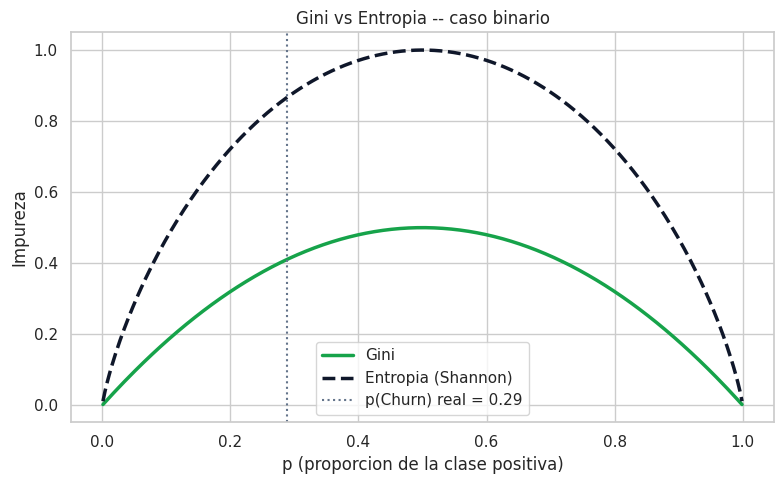

In [5]:
ps = np.linspace(0.001, 0.999, 300)
curva_gini = 1 - (ps**2 + (1 - ps)**2)
curva_entropia = -(ps * np.log2(ps) + (1 - ps) * np.log2(1 - ps))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ps, curva_gini, label="Gini", color="#16a34a", linewidth=2.5)
ax.plot(ps, curva_entropia, label="Entropia (Shannon)", color="#0f172a", linewidth=2.5, linestyle="--")
ax.axvline(p1_raiz, color="#64748b", linestyle=":", label=f"p(Churn) real = {p1_raiz:.2f}")
ax.set_xlabel("p (proporcion de la clase positiva)")
ax.set_ylabel("Impureza")
ax.set_title("Gini vs Entropia -- caso binario")
ax.legend()
plt.tight_layout()
plt.show()

Ambas curvas son cóncavas, valen 0 en los extremos ($p=0$ o $p=1$, nodo puro) y alcanzan su máximo en $p=0.5$ — pero la curva de entropía (máximo 1.0) es visiblemente más "puntiaguda" y de mayor magnitud que la de Gini (máximo 0.5), confirmando gráficamente su mayor sensibilidad a los cambios de distribución.

La pregunta práctica es si esta diferencia de forma cambia el árbol final. La siguiente celda entrena dos árboles idénticos salvo por el criterio, sobre la misma partición train/test.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
arbol_gini = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42).fit(Xtr, ytr)
arbol_entropia = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42).fit(Xtr, ytr)

print(f"Gini     -> acc train={arbol_gini.score(Xtr, ytr):.4f}  acc test={arbol_gini.score(Xte, yte):.4f}  hojas={arbol_gini.get_n_leaves()}")
print(f"Entropia -> acc train={arbol_entropia.score(Xtr, ytr):.4f}  acc test={arbol_entropia.score(Xte, yte):.4f}  hojas={arbol_entropia.get_n_leaves()}")
print(f"Predicciones identicas en test: {np.array_equal(arbol_gini.predict(Xte), arbol_entropia.predict(Xte))}")
print(f"Estructura identica (mismas variables y umbrales en cada nodo): {np.array_equal(arbol_gini.tree_.feature, arbol_entropia.tree_.feature) and np.allclose(arbol_gini.tree_.threshold, arbol_entropia.tree_.threshold)}")

Gini     -> acc train=0.7477  acc test=0.7584  hojas=8
Entropia -> acc train=0.7477  acc test=0.7584  hojas=8
Predicciones identicas en test: True
Estructura identica (mismas variables y umbrales en cada nodo): False


**Resultado:** ambos árboles alcanzan **exactamente la misma exactitud** de entrenamiento (0.7477) y de prueba (0.7584), el mismo número de hojas (8), y producen **predicciones idénticas** sobre el conjunto de prueba. Sin embargo, la estructura interna **no es idéntica**: Gini y Entropía eligen umbrales ligeramente distintos en algunos nodos profundos (por ejemplo, uno corta `antiguedad_meses <= 27.50` donde el otro corta `<= 29.50`) — pequeñas discrepancias que, en este dataset, terminan sin afectar ni una sola predicción final. Esto ilustra bien la regla práctica: la elección entre Gini y Entropía rara vez es la decisión que más impacta el desempeño de un árbol; suele ser una preferencia de costo computacional (Gini, al no usar logaritmos, es la opción por defecto de `scikit-learn` y la más usada en la práctica).

---
## 5. MSE (Reducción de Varianza): el criterio para regresión 📈

Cuando la variable objetivo $y$ es **continua** en lugar de categórica, "pureza" ya no puede definirse en términos de proporciones de clase. En su lugar, un nodo de regresión es "puro" cuando los valores de $y$ que contiene están muy próximos entre sí — es decir, cuando tienen **poca varianza**. El criterio estándar es el **Error Cuadrático Medio** (*Mean Squared Error*, MSE), calculado respecto al promedio del propio nodo:

$$\text{MSE}(t) = \frac{1}{N_t} \sum_{i \in t} (y_i - \bar{y}_t)^2$$

donde $\bar{y}_t$ es el promedio de $y$ entre las observaciones del nodo $t$. Nótese que esto es exactamente la **varianza muestral** de $y$ dentro del nodo — por eso a este criterio también se le llama *reducción de varianza*: CART busca la división que más reduce el promedio ponderado de MSE en los hijos, igual que buscaba reducir Gini o Entropía en clasificación.

`churn` (la variable objetivo de este módulo) es binaria, no continua, así que no sirve para ilustrar MSE. En el **Cuaderno 00 del Módulo 02 (Clasificación y Regresión)** ya se trabajó con árboles de regresión sobre `precio_millones`, una variable genuinamente continua. Aquí, en cambio, se aprovecha una columna continua **del propio dataset de este módulo** — `cargos_totales` (los cargos acumulados de cada cliente) — como variable objetivo ilustrativa, tratando el resto de columnas como predictores. Esto permite mostrar el mismo criterio recursivo de CART adaptado al caso continuo, con números calculados sobre datos ya familiares.

In [7]:
y_cargos = df_prep["cargos_totales"]
mse_raiz = ((y_cargos - y_cargos.mean())**2).mean()
print(f"cargos_totales: media={y_cargos.mean():.2f}  MSE(raiz) = Var(raiz) = {mse_raiz:,.2f}  (desviacion = {np.sqrt(mse_raiz):,.2f})")

cargos_totales: media=2596.93  MSE(raiz) = Var(raiz) = 3,517,018.51  (desviacion = 1,875.37)


Para ilustrar una división concreta, se usa la misma que `DecisionTreeRegressor` elige como raíz al entrenar sobre estos datos (verificado en la celda siguiente): **`antiguedad_meses <= 35.5`** — un resultado razonable, dado que `cargos_totales` se acumula con el tiempo de permanencia del cliente.

In [8]:
mask_split = df_prep["antiguedad_meses"] <= 35.5
y_izq_r, y_der_r = y_cargos[mask_split], y_cargos[~mask_split]
n_izq_r, n_der_r = len(y_izq_r), len(y_der_r)

mse_izq_r = ((y_izq_r - y_izq_r.mean())**2).mean()
mse_der_r = ((y_der_r - y_der_r.mean())**2).mean()
mse_hijos_r = (n_izq_r / len(y_cargos)) * mse_izq_r + (n_der_r / len(y_cargos)) * mse_der_r

print(f"Rama antiguedad_meses<=35.5: n={n_izq_r}  media={y_izq_r.mean():.2f}  MSE={mse_izq_r:,.2f}")
print(f"Rama antiguedad_meses>35.5:  n={n_der_r}  media={y_der_r.mean():.2f}  MSE={mse_der_r:,.2f}")
print(f"\nMSE ponderado hijos = {mse_hijos_r:,.2f}")
print(f"Reduccion de MSE (ganancia) = {mse_raiz - mse_hijos_r:,.2f}  ({(mse_raiz - mse_hijos_r) / mse_raiz * 100:.1f}% del MSE original)")

Rama antiguedad_meses<=35.5: n=1245  media=1308.20  MSE=908,821.17
Rama antiguedad_meses>35.5:  n=1255  media=3875.40  MSE=2,822,355.84

MSE ponderado hijos = 1,869,415.57
Reduccion de MSE (ganancia) = 1,647,602.94  (46.8% del MSE original)


**Lectura:** el MSE del nodo raíz es 3,517,018.51 (equivalente a una desviación estándar de \$1,875 en los cargos totales). Dividir por `antiguedad_meses <= 35.5` reduce el MSE ponderado a 1,869,415.57 — una **reducción de 1,647,602.94, el 46.8% del MSE original** — porque separa a los clientes nuevos (media \$1,308, MSE mucho menor: 908,821) de los antiguos (media \$3,875, MSE mayor: 2,822,356). Es una reducción enorme comparada con las divisiones de clasificación de la Sección 3 (que reducían Gini/Entropía en 10-15%), reflejando que `antiguedad_meses` es un predictor casi lineal de `cargos_totales` — tiene sentido, porque los cargos totales son, en esencia, cargos mensuales acumulados a lo largo del tiempo de permanencia.

In [9]:
feat_reg = ["antiguedad_meses", "cargo_mensual", "tipo_contrato_ord", "factura_electronica",
            "soporte_No", "soporte_Si", "soporte_Sin_Internet"]
X_reg = df_prep[feat_reg]

arbol_reg = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_reg, y_cargos)
print(f"R2 del arbol de regresion (max_depth=3): {arbol_reg.score(X_reg, y_cargos):.4f}")
print(f"Division elegida en la raiz: {feat_reg[arbol_reg.tree_.feature[0]]} <= {arbol_reg.tree_.threshold[0]:.2f}")

nodo_izq = arbol_reg.tree_.children_left[0]
print(f"\nImpureza (MSE) raiz sklearn:          {arbol_reg.tree_.impurity[0]:,.2f}   (calculo manual: {mse_raiz:,.2f})")
print(f"Impureza (MSE) hijo izquierdo sklearn: {arbol_reg.tree_.impurity[nodo_izq]:,.2f}   (calculo manual: {mse_izq_r:,.2f})")

R2 del arbol de regresion (max_depth=3): 0.8801
Division elegida en la raiz: antiguedad_meses <= 35.50

Impureza (MSE) raiz sklearn:          3,517,018.51   (calculo manual: 3,517,018.51)
Impureza (MSE) hijo izquierdo sklearn: 908,821.17   (calculo manual: 908,821.17)


La impureza reportada por `scikit-learn` en la raíz y en el hijo izquierdo coincide, hasta el redondeo, con el cálculo manual — confirmando que `DecisionTreeRegressor` con su criterio por defecto (`squared_error`) usa exactamente la fórmula de MSE presentada arriba. El árbol de regresión completo (`max_depth=3`) alcanza $R^2=0.8801$: `antiguedad_meses` y `cargo_mensual` son predictores muy fuertes de `cargos_totales`, coherente con la correlación de 0.79 entre `antiguedad_meses` y `cargos_totales` en los datos originales.

---
## 6. Tabla Comparativa: Gini vs. Entropía vs. MSE 📋

| Criterio | Tipo de tarea | Fórmula | Costo computacional | Cuándo usarlo |
|---|---|---|---|---|
| **Gini** | Clasificación | $1 - \sum_k p_k^2$ | Bajo (solo productos y sumas) | Opción por defecto en `scikit-learn`; preferible cuando el volumen de datos/candidatos a evaluar es grande y el costo del logaritmo de Entropía importa. |
| **Entropía / Ganancia de Información** | Clasificación | $-\sum_k p_k \log_2 p_k$ | Más alto (logaritmo por clase y nodo) | Cuando se desea una medida con raíces en teoría de la información, o al replicar algoritmos como ID3/C4.5 que la usan por diseño. En la práctica (Sección 4) produce resultados casi indistinguibles de Gini. |
| **MSE (Reducción de Varianza)** | Regresión | $\frac{1}{N_t}\sum_i (y_i - \bar{y}_t)^2$ | Bajo (media y suma de cuadrados) | Único criterio aplicable cuando $y$ es continua — no existe una noción de "proporción de clase" que optimizar. |

**Regla práctica de este módulo:** para los cuadernos de clasificación (churn) se usará `criterion='gini'` (el valor por defecto de `scikit-learn`, y el usado en el Cuaderno 00) salvo que se indique lo contrario; para problemas de regresión, `DecisionTreeRegressor` aplica MSE automáticamente.

---
## 7. Ejercicio Práctico Guiado: verificando Gini y Entropía en un nodo interno 📝

**Contexto:** las Secciones 2 y 3 calcularon Gini y Entropía a mano solo para el nodo raíz y para la división raíz. Vas a repetir el ejercicio para un nodo **interno** del árbol `arbol_gini` (Sección 4, entrenado sobre `Xtr, ytr` con `max_depth=3`): el **nodo 2**, definido por `tipo_contrato_ord <= 0.5` Y `cargo_mensual <= 74.515`, que a su vez se divide sobre `antiguedad_meses <= 27.5`.

**Tu misión:**
1. Construye una máscara booleana sobre `Xtr` para el nodo 2: `(Xtr["tipo_contrato_ord"] <= 0.5) & (Xtr["cargo_mensual"] <= 74.515)`, y usa `ytr` con esa máscara para obtener `y_nodo2`.
2. Calcula `p1_n2` (proporción de `Churn` en `y_nodo2`) y con ella el Gini (`gini_n2`) y la Entropía (`ent_n2`) del nodo.
3. Construye las dos submáscaras para la división `antiguedad_meses <= 27.5` (izquierda) y `antiguedad_meses > 27.5` (derecha) **dentro** del nodo 2.
4. Calcula Gini y Entropía de cada submáscara (hoja izquierda y hoja derecha), y con ellas la ganancia de Gini y la Ganancia de Información de esta división.
5. Verifica tu `gini_n2` contra `arbol_gini.tree_.impurity[2]` (el valor que `scikit-learn` calculó internamente para ese mismo nodo).

In [10]:
### TU CODIGO AQUI ###
# 1. Mascara y subconjunto del nodo 2
nodo2_mask = None
y_nodo2 = None

# 2. Gini y Entropia del nodo 2
p1_n2 = None
gini_n2 = None
ent_n2 = None
print("Nodo 2 -> n:", None, " p(Churn):", None, " Gini:", None, " Entropia:", None)

# 3. Submascaras de la division antiguedad_meses <= 27.5
sub_izq_mask = None
sub_der_mask = None

# 4. Gini/Entropia de cada hoja y ganancias de la division
gini_izq_hoja = None
gini_der_hoja = None
ent_izq_hoja = None
ent_der_hoja = None
ganancia_gini_n2 = None
ganancia_info_n2 = None
print("Ganancia Gini:", None, " Ganancia Informacion:", None)

# 5. Verificacion contra sklearn
print("gini_n2 calculado:", None, " vs arbol_gini.tree_.impurity[2]:", None)

Nodo 2 -> n: None  p(Churn): None  Gini: None  Entropia: None
Ganancia Gini: None  Ganancia Informacion: None
gini_n2 calculado: None  vs arbol_gini.tree_.impurity[2]: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Mascara y subconjunto del nodo 2
nodo2_mask = (Xtr["tipo_contrato_ord"] <= 0.5) & (Xtr["cargo_mensual"] <= 74.515)
y_nodo2 = ytr[nodo2_mask]

# 2. Gini y Entropia del nodo 2
p1_n2 = (y_nodo2 == 1).mean()
p0_n2 = 1 - p1_n2
gini_n2 = 1 - (p0_n2**2 + p1_n2**2)
ent_n2 = -(p0_n2 * np.log2(p0_n2) + p1_n2 * np.log2(p1_n2))
print("Nodo 2 -> n:", len(y_nodo2), " p(Churn):", round(p1_n2, 4), " Gini:", round(gini_n2, 4), " Entropia:", round(ent_n2, 4))

# 3. Submascaras de la division antiguedad_meses <= 27.5
sub_izq_mask = nodo2_mask & (Xtr["antiguedad_meses"] <= 27.5)
sub_der_mask = nodo2_mask & (Xtr["antiguedad_meses"] > 27.5)
y_sub_izq = ytr[sub_izq_mask]
y_sub_der = ytr[sub_der_mask]

# 4. Gini/Entropia de cada hoja y ganancias de la division
p1_si = (y_sub_izq == 1).mean(); p0_si = 1 - p1_si
p1_sd = (y_sub_der == 1).mean(); p0_sd = 1 - p1_sd
gini_izq_hoja = 1 - (p0_si**2 + p1_si**2)
gini_der_hoja = 1 - (p0_sd**2 + p1_sd**2)
ent_izq_hoja = -(p0_si * np.log2(p0_si) + p1_si * np.log2(p1_si))
ent_der_hoja = -(p0_sd * np.log2(p0_sd) + p1_sd * np.log2(p1_sd))

n2_total = len(y_nodo2)
gini_hijos_n2 = (len(y_sub_izq) / n2_total) * gini_izq_hoja + (len(y_sub_der) / n2_total) * gini_der_hoja
ent_hijos_n2 = (len(y_sub_izq) / n2_total) * ent_izq_hoja + (len(y_sub_der) / n2_total) * ent_der_hoja
ganancia_gini_n2 = gini_n2 - gini_hijos_n2
ganancia_info_n2 = ent_n2 - ent_hijos_n2
print("Ganancia Gini:", round(ganancia_gini_n2, 4), " Ganancia Informacion:", round(ganancia_info_n2, 4))

# 5. Verificacion contra sklearn
print("gini_n2 calculado:", round(gini_n2, 4), " vs arbol_gini.tree_.impurity[2]:", round(arbol_gini.tree_.impurity[2], 4))
```

Resultados: el nodo 2 tiene `n=518`, `p(Churn)=0.3166`, `Gini=0.4327` y `Entropia=0.9006`. La división sobre `antiguedad_meses <= 27.5` produce una hoja izquierda (`n=204`, `Gini=0.4961`, `Entropia=0.9944` — casi tan impura como el propio nodo 2) y una hoja derecha (`n=314`, `Gini=0.3500`, `Entropia=0.7712` — más pura), con una **ganancia de Gini de 0.0252** y una **Ganancia de Información de 0.0416**. El `gini_n2=0.4327` calculado a mano coincide exactamente con `arbol_gini.tree_.impurity[2]=0.4327` reportado por `scikit-learn`, confirmando —igual que en la Sección 3— que las fórmulas manuales replican con precisión lo que CART calcula internamente en cada nodo, sin importar qué tan profundo esté ese nodo en el árbol.

</details>

---
## 8. Resumen Ejecutivo del Cuaderno 01 📌

1. **CART necesita una función numérica de "pureza" para comparar divisiones candidatas** — este cuaderno formalizó las tres funciones estándar: Gini y Entropía para clasificación, MSE para regresión.
2. **Gini** ($I_G = 1 - \sum p_k^2$, rango $[0, 0.5]$ en caso binario) y **Entropía** ($H = -\sum p_k \log_2 p_k$, rango $[0, 1]$) coinciden en la dirección de sus juicios: sobre el nodo raíz de `abandono_clientes_telecom.csv` ($n=2500$, $p(\text{Churn})=0.2888$), $I_G=0.4108$ y $H=0.8672$; y ambos coinciden en que la división `tipo_contrato_ord <= 0.5` es útil (ganancia Gini=0.0427, Ganancia de Información=0.0798).
3. **En la práctica, Gini y Entropía producen árboles casi idénticos:** entrenados con `max_depth=3` sobre los mismos datos, ambos criterios lograron exactamente la misma exactitud (train=0.7477, test=0.7584) y las mismas predicciones, aunque con umbrales ligeramente distintos en nodos profundos — Gini es la opción por defecto de `scikit-learn` por su menor costo computacional (sin logaritmos).
4. **MSE (Reducción de Varianza) adapta el mismo principio al caso continuo:** usando `cargos_totales` como variable objetivo ilustrativa, dividir por `antiguedad_meses <= 35.5` redujo el MSE de 3,517,018.51 a un promedio ponderado de 1,869,415.57 (**46.8% de reducción**), un resultado verificado exactamente contra `DecisionTreeRegressor.tree_.impurity`.
5. **Los tres criterios comparten una misma lógica recursiva:** en cada nodo, CART evalúa la reducción de impureza (Gini, Entropía o MSE, según la tarea) de cada división candidata y elige la mejor — la diferencia entre criterios está en cómo se mide "impureza", no en el procedimiento de búsqueda descrito en el Cuaderno 00.
6. **Siguiente paso:** con la mecánica completa de CART ya formalizada (Cuaderno 00: cómo se construye el árbol; Cuaderno 01: cómo se elige cada división), el **Cuaderno 02** aborda la **poda** (*pruning*) como primera estrategia para controlar la alta varianza demostrada en el Cuaderno 00, seguida de **Bagging** (Cuaderno 03) y **Bosques Aleatorios** (Cuaderno 04).

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Árboles y Bosques Aleatorios</i>
  </p>
</div>